<a href="https://colab.research.google.com/github/Adnaan-khan/Practice-projects/blob/main/Diabetic-Readmission-Prediction/Diabetics_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Predicting 30-Day Hospital Readmission Risk Among Diabetic Patients Using Machine Learning**


**Objective**
The objective of this project was to develop predictive machine learning models to identify diabetic patients who are at higher risk of hospital readmission within 30 days, using demographic, clinical, and hospitalization-related variables.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:

# Load dataset
df = pd.read_csv("diabetic_data.csv")

In [ ]:
# Check first few rows
df.head()


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


**Dataset Overview
Dataset: Diabetic patient hospital encounter data
Records: 101,766 patient encounters
Features: 50 variables
Prediction Target:
1 Readmitted within 30 days
0 Not readmitted within 30 days**

In [ ]:
print("Shape of dataset;", df.shape)

Shape of dataset; (101766, 50)


In [ ]:
df["readmitted_30"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)
df["readmitted"].value_counts()

,count
readmitted,
NO,54864
>30,35545
<30,11357


In [ ]:
df["readmitted"] = df["readmitted"].apply(lambda x: 1 if x == "<30" else 0)
df["readmitted"].value_counts(normalize=True) * 100

,proportion
readmitted,
0,88.840084
1,11.159916


In [ ]:
df = df.replace("?", np.nan)
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing.head(15)

,0
weight,96.858479
max_glu_serum,94.746772
A1Cresult,83.277322
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636
patient_nbr,0.000000


In [ ]:
# Drop columns with too many missing values or IDs
drop_cols = [
    "encounter_id",
    "patient_nbr",
    "weight",
    "payer_code",
    "medical_specialty",
    "readmitted"
]

# Filter out columns that do not exist in the DataFrame
existing_cols = [col for col in drop_cols if col in df.columns]

df = df.drop(columns=existing_cols)

df.shape

(101766, 45)

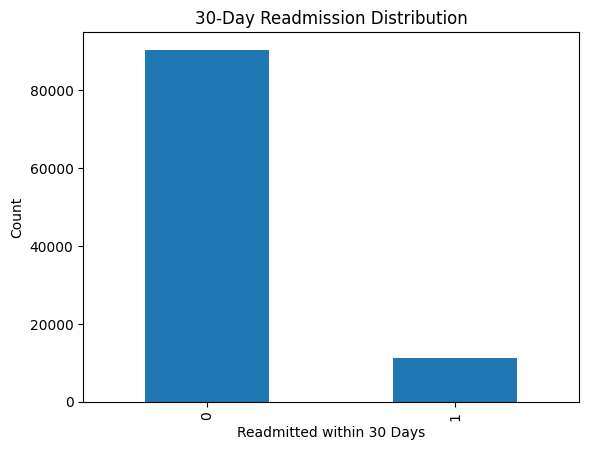

In [ ]:
df["readmitted_30"].value_counts().plot(kind="bar")
plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmitted within 30 Days")
plt.ylabel("Count")
plt.show()

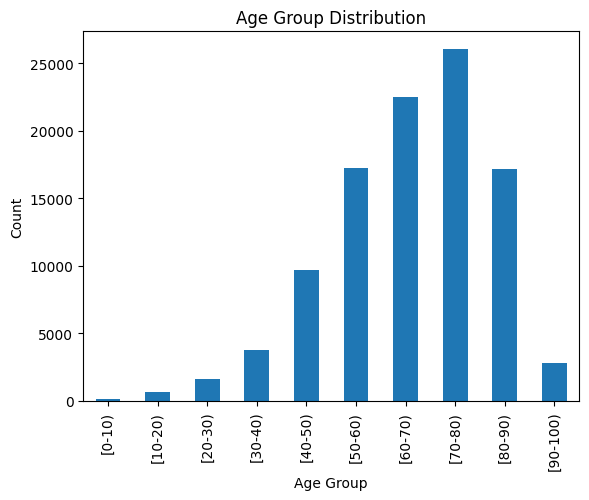

In [ ]:
df["age"].value_counts().sort_index().plot(kind="bar")
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

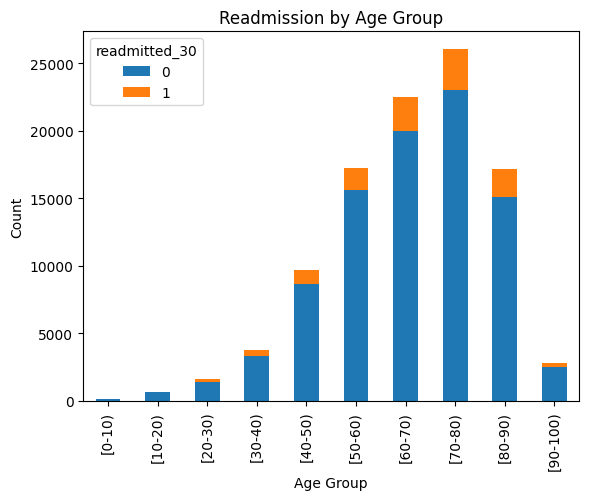

In [ ]:
pd.crosstab(df["age"], df["readmitted_30"]).plot(kind="bar", stacked=True)
plt.title("Readmission by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

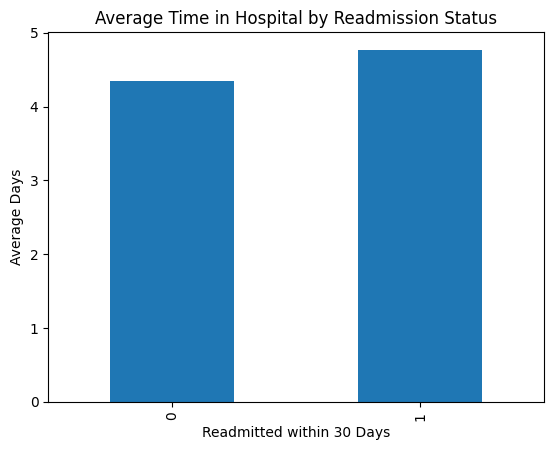

In [ ]:
df.groupby("readmitted_30")["time_in_hospital"].mean().plot(kind="bar")
plt.title("Average Time in Hospital by Readmission Status")
plt.xlabel("Readmitted within 30 Days")
plt.ylabel("Average Days")
plt.show()

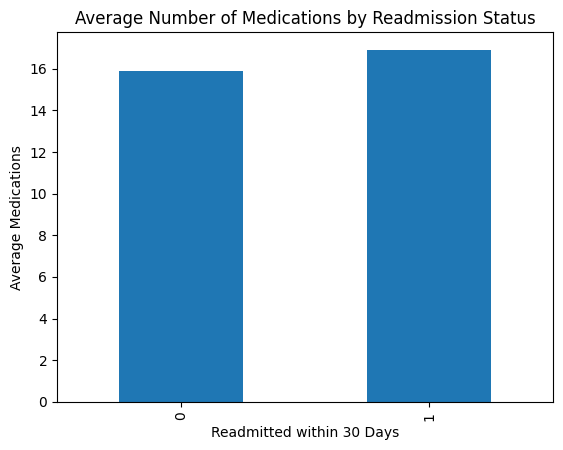

In [ ]:
df.groupby("readmitted_30")["num_medications"].mean().plot(kind="bar")
plt.title("Average Number of Medications by Readmission Status")
plt.xlabel("Readmitted within 30 Days")
plt.ylabel("Average Medications")
plt.show()

In [ ]:
X = df.drop(columns=["readmitted_30"])
y = df["readmitted_30"]

categorical_cols = X.select_dtypes(include=["object"]).columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns

print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))

Categorical columns: 33
Numeric columns: 11


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

In [ ]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.6442468310897121
              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18083
           1       0.17      0.55      0.26      2271

    accuracy                           0.64     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.64      0.71     20354



**Interpretation of Logistic Regression Results
Model Performance
Accuracy 64.4%
Class 0 (No Readmission)
Precision 0.92
Recall 0.66
Class 1 (Readmission)
Precision  0.17
Recall  0.55
F1 Score  0.26**

In [ ]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8889653139432052
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.76      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.83      0.50      0.48     20354
weighted avg       0.87      0.89      0.84     20354



In [ ]:
gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.8884740100226
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.52      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.70      0.50      0.48     20354
weighted avg       0.85      0.89      0.84     20354



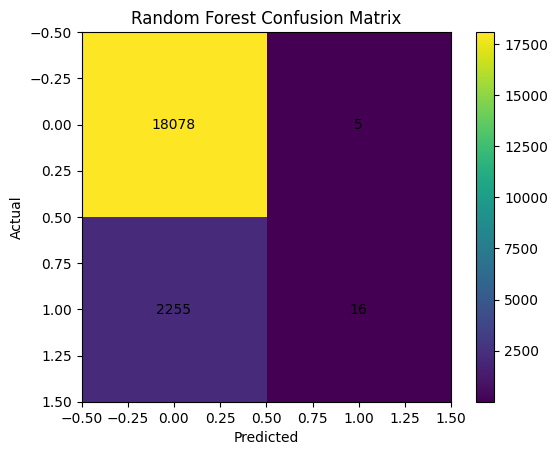

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.imshow(cm)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm[0])):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

**Interpretation**:
Although Random Forest achieved high overall accuracy (~88.9%), the confusion matrix shows that the model primarily predicted patients as not readmitted.
This resulted in extremely low identification of actual readmission events.
This behavior indicates sensitivity to class imbalance, where the majority class dominates predictions.
From a healthcare perspective, missing high-risk patients could limit the usefulness of the model for preventive intervention**

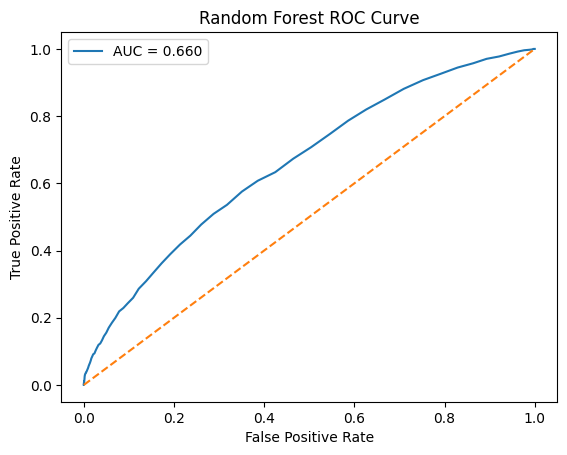

In [ ]:
y_proba = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

**The model has about a 66% chance of correctly ranking a readmitted patient higher than a non-readmitted patient, showing moderate predictive ability**

In [ ]:
encoded_features = rf_model.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_cols)
all_features = list(encoded_features) + list(numeric_cols)

importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df.head(20)

,Feature,Importance
2274,num_lab_procedures,0.051461
2276,num_medications,0.047832
2279,number_inpatient,0.039627
2273,time_in_hospital,0.037947
2271,discharge_disposition_id,0.030320
2280,number_diagnoses,0.027679
2275,num_procedures,0.027057
2270,admission_type_id,0.020442
2272,admission_source_id,0.017568
2277,number_outpatient,0.013785


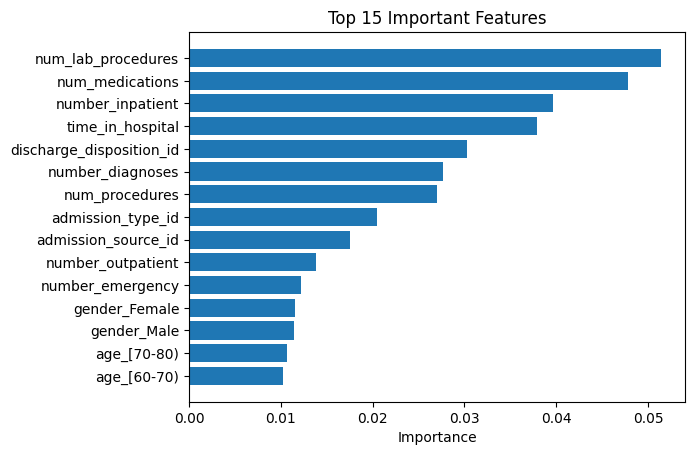

In [ ]:
top_features = feature_importance_df.head(15)

plt.barh(top_features["Feature"], top_features["Importance"])
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
pip install graphviz


In [ ]:
from sklearn.tree import export_graphviz
import graphviz
from sklearn.ensemble import RandomForestClassifier

# Apply the preprocessor to X_train to transform categorical features
# We need to fit_transform the preprocessor here as it's being used outside the pipeline
X_train_transformed = preprocessor.fit_transform(X_train)

rf = RandomForestClassifier(n_estimators=1, random_state=42)
rf.fit(X_train_transformed, y_train)

RandomForestClassifier(n_estimators=1, random_state=42)

In [ ]:
RandomForestClassifier(n_estimators=1)

RandomForestClassifier(n_estimators=1)

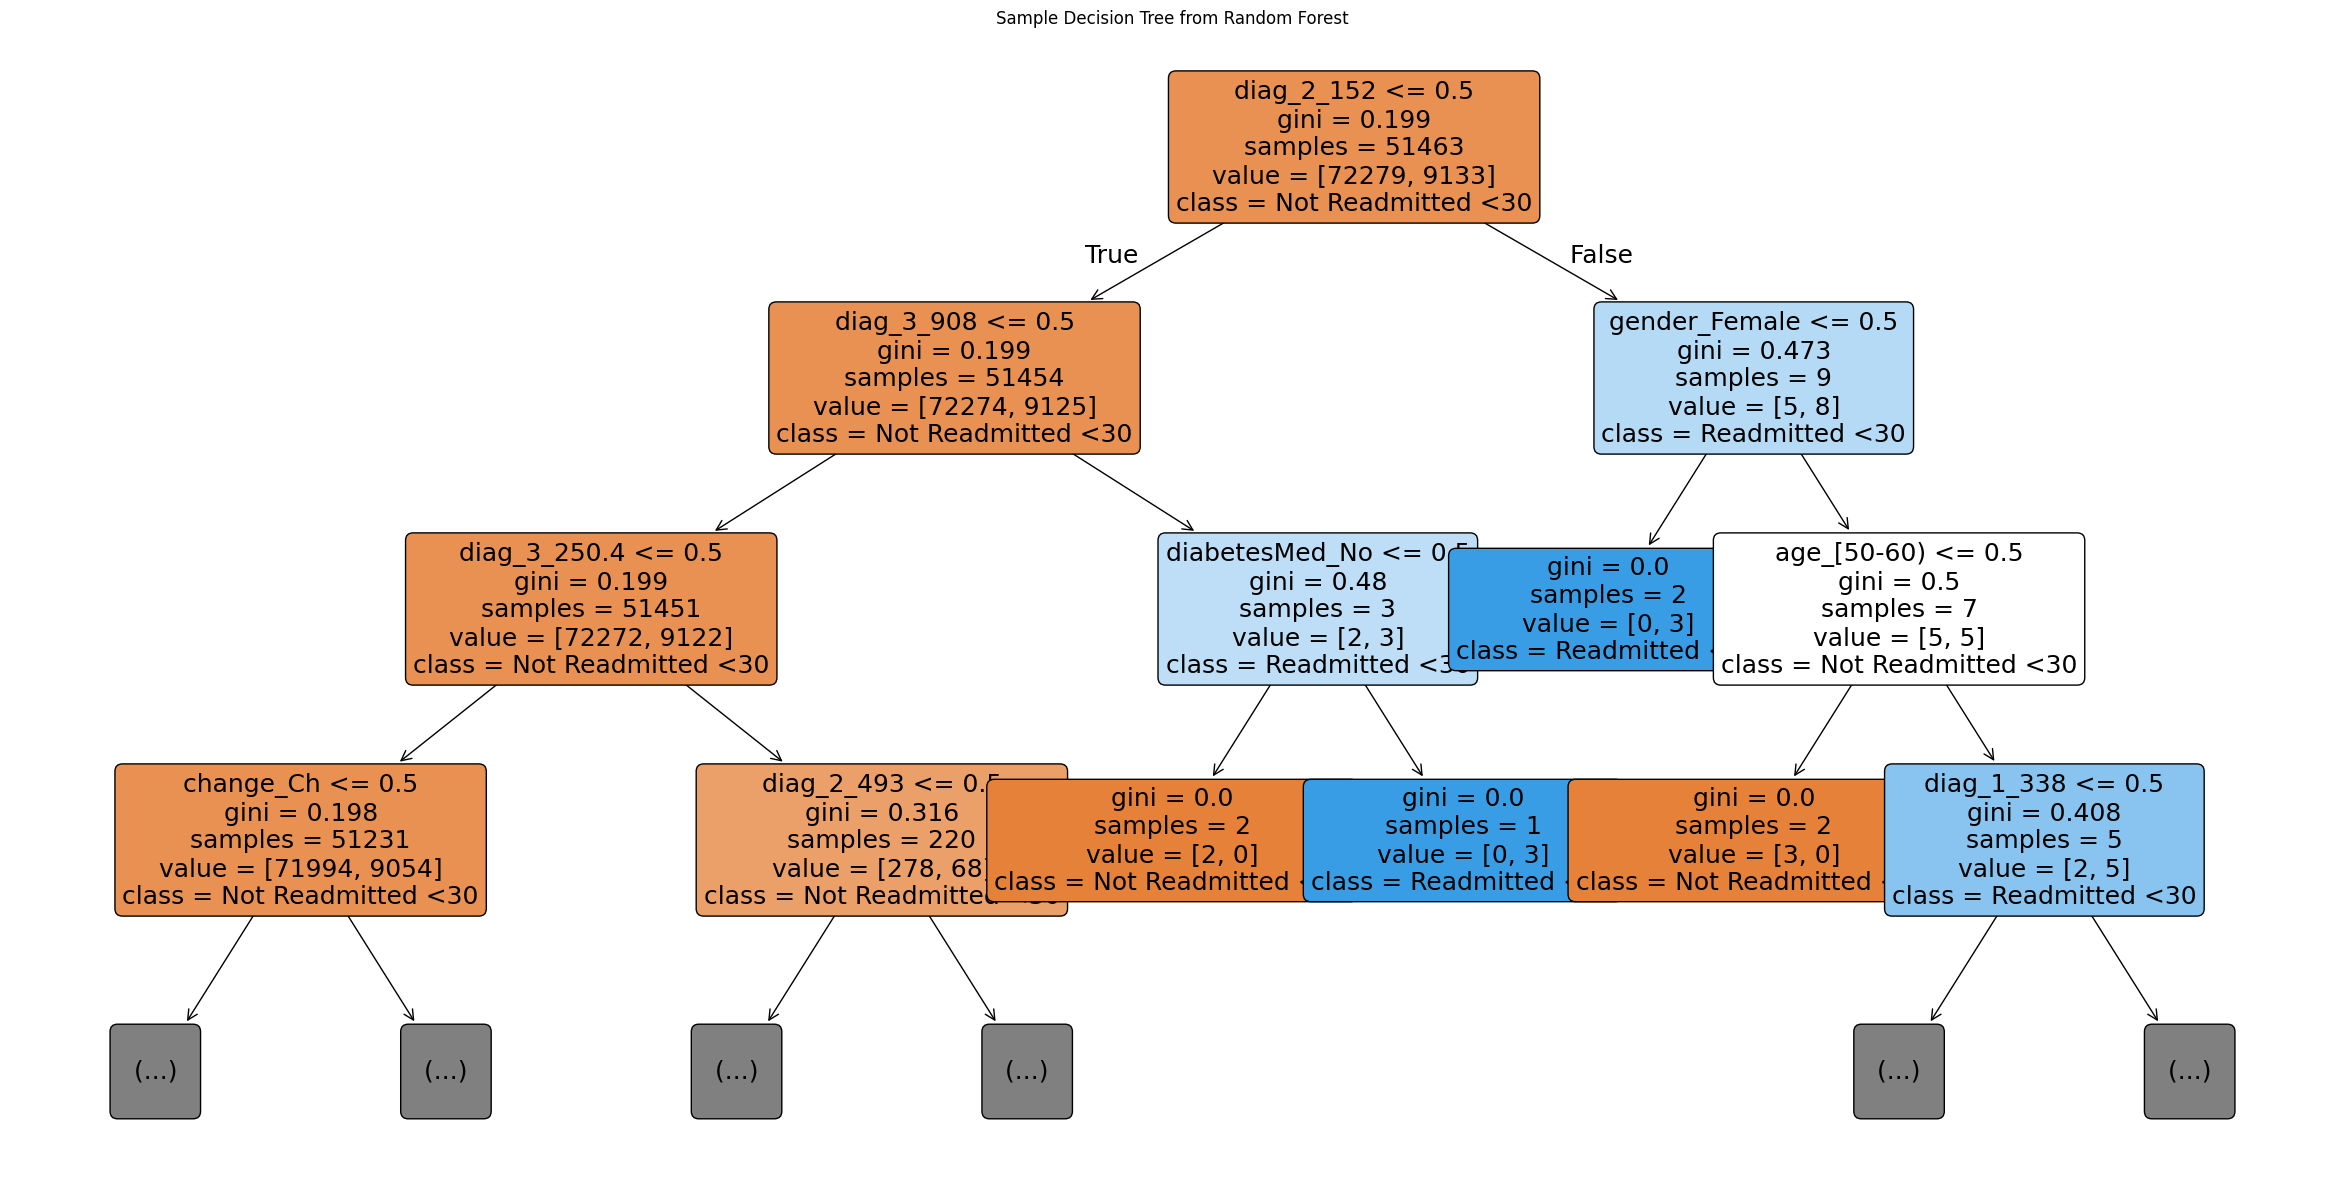

In [ ]:
from sklearn.tree import plot_tree

single_tree = rf.estimators_[0]

plt.figure(figsize=(30, 15))

plot_tree(
    single_tree,
    feature_names=all_features,
    class_names=["Not Readmitted <30", "Readmitted <30"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=18

)

plt.title("Sample Decision Tree from Random Forest")
plt.show()

**Interpretation**

The figure represents a sample decision tree extracted from the Random Forest model used to predict 30-day hospital readmission among diabetic patients.

The model makes decisions by splitting patient records based on clinical variables such as:

Diagnosis indicators (diag_1, diag_2, diag_3)
Diabetes medication status
Medication changes
Age
Gender

Each node shows:

Split rule - condition used for decision making
Gini - impurity measure (lower values indicate better separation)
Samples - number of patient records in that node
Value - distribution across readmission classes
Class - predicted outcome

The tree indicates that diagnosis-related variables were among the strongest factors influencing prediction decisions, suggesting that underlying clinical conditions contributed substantially to readmission outcomes.

Orange nodes represent:
- Not Readmitted

Blue nodes represent:
-Readmitted within 30 days

The hidden branches (…) indicate additional decision paths omitted for readability

**Conclusion**

This project explored machine learning approaches to predict 30-day hospital readmission among diabetic patients using healthcare encounter data.

Among the evaluated models, Logistic Regression demonstrated better identification of readmission cases, while Random Forest achieved higher overall accuracy but limited detection of high-risk patients.

ROC analysis showed moderate discrimination performance (AUC = 0.660), emphasizing that healthcare models should be evaluated beyond accuracy alone.

The project demonstrates the application of predictive analytics in healthcare to support patient risk assessment and data-driven decision-making.